<a href="https://colab.research.google.com/github/krithi-ks/PetroVision/blob/main/notebooks/computer-vision/PetroVision_U-Net_Improvement_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PetroVision — U-Net Improvement Experiment

## Experiment ID
CV-UNET-002

## Objective

Evaluate whether a Dice-focused segmentation loss improves
binary petroleum-region segmentation compared with the
CV-UNET-001 baseline.

## Baseline Experiment

CV-UNET-001

- U-Net
- BCE + Dice loss
- 256 × 256 input
- Adam optimizer
- Learning rate: 1e-3
- 20 epochs
- LADOS dataset

## Changed Factor

Segmentation loss.

### Baseline
BCE + Dice Loss

### Improvement
Dice Loss

All other major training and evaluation settings are kept unchanged.

## Dataset

LADOS semantic segmentation dataset.

## Task

Binary segmentation of:

- Oil
- Emulsion
- Sheen

as the petroleum-related target class.

## Important Scientific Boundary

The model performs visual segmentation of annotated image regions.
It does not chemically identify petroleum or estimate physical
oil concentration, thickness, or volume.

## 1. Environment & GPU

Verify the Python, PyTorch, CUDA, and GPU environment used for
the experiment.

In [ ]:
import sys
import torch

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU: CPU")

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Project Setup

Clone the PetroVision repository and make the project source
code importable.

In [ ]:
!git clone https://github.com/krithi-ks/PetroVision.git
%cd PetroVision

from pathlib import Path

print("Project root:", Path.cwd())
print("\nProject files:")
for item in sorted(Path(".").iterdir()):
    print(" -", item.name)

Cloning into 'PetroVision'...
remote: Enumerating objects: 122, done.
remote: Counting objects: 100% (122/122), done.
remote: Compressing objects: 100% (93/93), done.
remote: Total 122 (delta 30), reused 54 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (122/122), 988.44 KiB | 8.52 MiB/s, done.
Resolving deltas: 100% (30/30), done.
/content/PetroVision/PetroVision
Project root: /content/PetroVision/PetroVision

Project files:
 - .git
 - .gitignore
 - README.md
 - app
 - data
 - docs
 - notebooks
 - references
 - reports
 - requirements.txt
 - results
 - src


## 3. Dataset Setup

The LADOS dataset is stored in Google Drive and extracted into
the PetroVision project directory.

The same dataset version and split used for CV-UNET-001 are retained
for CV-UNET-002 to ensure a controlled comparison.

In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path

ZIP_PATH = Path(
    "/content/drive/MyDrive/PetroVision/datasets/"
    "PetroVision.v1i.png-mask-semantic.zip"
)

print("ZIP exists:", ZIP_PATH.exists())
print("ZIP:", ZIP_PATH)

ZIP exists: True
ZIP: /content/drive/MyDrive/PetroVision/datasets/PetroVision.v1i.png-mask-semantic.zip


In [ ]:
import zipfile

DATASET_ROOT = PROJECT_ROOT / "data" / "lados"

if not DATASET_ROOT.exists():
    DATASET_ROOT.mkdir(parents=True, exist_ok=True)

if not (DATASET_ROOT / "train").exists():
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(DATASET_ROOT)
    print("Dataset extracted to:", DATASET_ROOT)
else:
    print("Dataset already exists:", DATASET_ROOT)


Dataset extracted to: /content/PetroVision/data/lados


In [ ]:
from pathlib import Path

print("LADOS dataset verification")
print("=" * 50)

for split in ["train", "valid", "test"]:
    split_path = DATASET_ROOT / split

    files = list(split_path.iterdir())

    image_count = sum(
        1 for f in files
        if f.suffix.lower() in [".jpg", ".jpeg", ".png"]
        and "_mask" not in f.stem
    )

    mask_count = sum(
        1 for f in files
        if "_mask" in f.stem
    )

    print(
        f"{split:5s} | "
        f"images: {image_count} | "
        f"masks: {mask_count}"
    )

LADOS dataset verification
train | images: 2370 | masks: 2370
valid | images: 675 | masks: 675
test  | images: 343 | masks: 343


## 4. Dependencies & Imports

Import the PetroVision dataset, U-Net model, and segmentation losses
from the repository.

In [ ]:
import sys
import numpy as np
import torch
from torch.utils.data import DataLoader

from pathlib import Path

PROJECT_ROOT = Path("/content/PetroVision")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.vision.lados_dataset import LADOSDataset
from src.vision.unet import UNet
from src.vision.segmentation_loss import DiceLoss, BCEDiceLoss

print("PetroVision modules imported successfully.")

PetroVision modules imported successfully.


## 5. PetroVision Model & Loss

CV-UNET-002 retains the same U-Net architecture as CV-UNET-001.

The experimental change is the segmentation loss:

CV-UNET-001 → BCE + Dice Loss

### CV-UNET-002 → Dice Loss

In [ ]:
import inspect

print("DiceLoss implementation:")
print(inspect.getsource(DiceLoss))

DiceLoss implementation:
class DiceLoss(nn.Module):
    """
    Dice loss for binary segmentation.

    Dice coefficient:

        Dice = 2 * intersection / (prediction + target)

    Dice loss:

        Dice Loss = 1 - Dice
    """

    def __init__(self, smooth=1.0):

        super().__init__()

        self.smooth = smooth

    def forward(self, logits, targets):

        # Convert logits to probabilities
        probabilities = torch.sigmoid(logits)

        # Flatten each sample
        probabilities = probabilities.view(
            probabilities.size(0),
            -1
        )

        targets = targets.view(
            targets.size(0),
            -1
        )

        # Intersection
        intersection = (
            probabilities * targets
        ).sum(dim=1)

        # Dice coefficient
        dice = (
            2.0 * intersection
            + self.smooth
        ) / (
            probabilities.sum(dim=1)
            + targets.sum(dim=1)
            + self.smooth
  

In [ ]:
print("BCEDiceLoss implementation:")
print(inspect.getsource(BCEDiceLoss))

BCEDiceLoss implementation:
class BCEDiceLoss(nn.Module):
    """
    Combined Binary Cross-Entropy + Dice Loss.

    BCE operates directly on logits using
    BCEWithLogitsLoss.

    Dice loss internally applies sigmoid.
    """

    def __init__(
        self,
        bce_weight=0.5,
        dice_weight=0.5,
        smooth=1.0
    ):

        super().__init__()

        self.bce_weight = bce_weight
        self.dice_weight = dice_weight

        self.bce = nn.BCEWithLogitsLoss()

        self.dice = DiceLoss(
            smooth=smooth
        )

    def forward(self, logits, targets):

        bce_loss = self.bce(
            logits,
            targets
        )

        dice_loss = self.dice(
            logits,
            targets
        )

        total_loss = (
            self.bce_weight * bce_loss
            + self.dice_weight * dice_loss
        )

        return total_loss



## 6. Experiment Configuration

The following settings are kept identical to CV-UNET-001 wherever
possible. Only the segmentation loss is changed.

In [ ]:
SEED = 42

import random

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


IMAGE_SIZE = (256, 256)
BATCH_SIZE = 16
EPOCHS = 20
LEARNING_RATE = 1e-3

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Experiment ID:", "CV-UNET-002")
print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)
print("Device:", DEVICE)

Experiment ID: CV-UNET-002
Image size: (256, 256)
Batch size: 16
Epochs: 20
Learning rate: 0.001
Device: cuda


## 7. Model & Optimizer

The CV-UNET-002 experiment uses the same lightweight U-Net architecture
as the CV-UNET-001 baseline.

Keeping the model architecture unchanged allows the experiment to focus
specifically on the effect of changing the segmentation loss function.

For CV-UNET-002:

- Model: Lightweight U-Net
- Input channels: 3 (RGB)
- Output channels: 1
- Input image size: 256 × 256 pixels
- Trainable parameters: 1,942,577
- Loss function: Dice Loss
- Optimizer: Adam
- Learning rate: 0.001

The primary experimental change from CV-UNET-001 is the use of Dice Loss
alone instead of the combined BCE + Dice loss.

The model is initialized with the same architecture and training
configuration used in the baseline experiment to maintain a controlled
comparison.

In [ ]:
train_dataset = LADOSDataset(
    DATASET_ROOT,
    split="train",
    image_size=IMAGE_SIZE,
    augment=True
)

valid_dataset = LADOSDataset(
    DATASET_ROOT,
    split="valid",
    image_size=IMAGE_SIZE,
    augment=False
)

test_dataset = LADOSDataset(
    DATASET_ROOT,
    split="test",
    image_size=IMAGE_SIZE,
    augment=False
)

print("Train:", len(train_dataset))
print("Valid:", len(valid_dataset))
print("Test :", len(test_dataset))

Train: 2370
Valid: 675
Test : 343


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Valid batches:", len(valid_loader))
print("Test batches :", len(test_loader))

Train batches: 149
Valid batches: 43
Test batches : 22


In [ ]:
model = UNet(
    in_channels=3,
    out_channels=1
).to(DEVICE)

criterion = DiceLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("Trainable parameters:", trainable_params)
print("Loss:", criterion.__class__.__name__)

Trainable parameters: 1942577
Loss: DiceLoss


## 8. Training

CV-UNET-002 is trained using the same dataset, U-Net architecture,
input resolution, optimizer, learning rate, batch size, and number
of epochs as CV-UNET-001.

The only experimental change is the segmentation loss:

CV-UNET-001 → BCE + Dice Loss

CV-UNET-002 → Dice Loss

The checkpoint with the lowest validation loss is retained as the
best model for subsequent test evaluation.

In [ ]:
from pathlib import Path
import torch

CHECKPOINT_DIR = PROJECT_ROOT / "models"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = CHECKPOINT_DIR / "unet_improvement_best.pt"

train_losses = []
val_losses = []

best_val_loss = float("inf")
history = []

for epoch in range(1, EPOCHS + 1):

    # ---------------------------------------------------------
    # Training
    # ---------------------------------------------------------
    model.train()

    train_loss_sum = 0.0

    for images, masks in train_loader:

        images = images.to(DEVICE, non_blocking=True)
        masks = masks.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)

        loss = criterion(logits, masks)

        loss.backward()

        optimizer.step()

        train_loss_sum += loss.item()

    train_loss = train_loss_sum / len(train_loader)

    # ---------------------------------------------------------
    # Validation
    # ---------------------------------------------------------
    model.eval()

    val_loss_sum = 0.0

    with torch.no_grad():

        for images, masks in valid_loader:

            images = images.to(DEVICE, non_blocking=True)
            masks = masks.to(DEVICE, non_blocking=True)

            logits = model(images)

            loss = criterion(logits, masks)

            val_loss_sum += loss.item()

    val_loss = val_loss_sum / len(valid_loader)

    # ---------------------------------------------------------
    # Record history
    # ---------------------------------------------------------
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "validation_loss": val_loss
    })

    # ---------------------------------------------------------
    # Save best model
    # ---------------------------------------------------------
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            {
                "experiment_id": "CV-UNET-002",
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "validation_loss": val_loss,
                "loss_function": "DiceLoss"
            },
            BEST_MODEL_PATH
        )

        best_marker = "  ← best"

    else:

        best_marker = ""

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Validation Loss: {val_loss:.6f}"
        f"{best_marker}"
    )


print("\n" + "=" * 70)
print("CV-UNET-002 TRAINING COMPLETE")
print("=" * 70)

print(f"Best validation loss: {best_val_loss:.6f}")
print(f"Best model: {BEST_MODEL_PATH}")

Epoch 01/20 | Train Loss: 0.425531 | Validation Loss: 0.398802  ← best
Epoch 02/20 | Train Loss: 0.373428 | Validation Loss: 0.355076  ← best
Epoch 03/20 | Train Loss: 0.350242 | Validation Loss: 0.341842  ← best
Epoch 04/20 | Train Loss: 0.344828 | Validation Loss: 0.333556  ← best
Epoch 05/20 | Train Loss: 0.341648 | Validation Loss: 0.345159
Epoch 06/20 | Train Loss: 0.337000 | Validation Loss: 0.325502  ← best
Epoch 07/20 | Train Loss: 0.329588 | Validation Loss: 0.326626
Epoch 08/20 | Train Loss: 0.331004 | Validation Loss: 0.322674  ← best
Epoch 09/20 | Train Loss: 0.325207 | Validation Loss: 0.328809
Epoch 10/20 | Train Loss: 0.324420 | Validation Loss: 0.333599
Epoch 11/20 | Train Loss: 0.321634 | Validation Loss: 0.310075  ← best
Epoch 12/20 | Train Loss: 0.312231 | Validation Loss: 0.338019
Epoch 13/20 | Train Loss: 0.316918 | Validation Loss: 0.328032
Epoch 14/20 | Train Loss: 0.313582 | Validation Loss: 0.320987
Epoch 15/20 | Train Loss: 0.314819 | Validation Loss: 0.345593

## Training Analysis

The training and validation loss curves are visualized to examine the learning
behaviour of CV-UNET-002.

This experiment uses Dice Loss as the segmentation loss function, while the
baseline CV-UNET-001 uses a combined BCE + Dice loss.

The visualization helps identify:

- whether the model is learning during training
- how validation loss changes across epochs
- possible overfitting or training instability
- the epoch corresponding to the best validation loss

The training and validation curves are interpreted together rather than using
training loss alone.

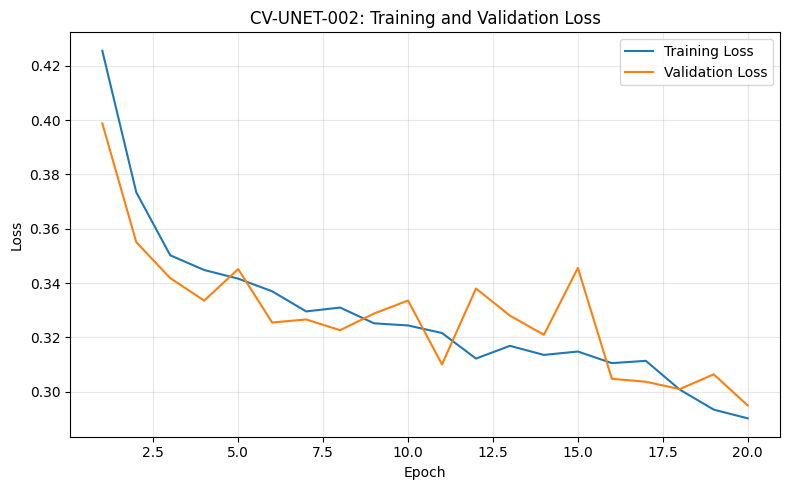

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path

figures_dir = Path("/content/PetroVision/results/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    train_losses,
    label="Training Loss"
)

plt.plot(
    epochs_range,
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CV-UNET-002: Training and Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    figures_dir / "cv_unet_002_loss_curve.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 9. Test Evaluation

The best CV-UNET-002 checkpoint is evaluated on the held-out
LADOS test set.

The same test set and threshold used for CV-UNET-001 are retained
to enable a controlled comparison.

Metrics:

- IoU
- Dice
- Precision
- Recall
- Accuracy

In [ ]:
import torch

# ---------------------------------------------------------
# Load best CV-UNET-002 checkpoint
# ---------------------------------------------------------

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()

print("Loaded experiment:", checkpoint["experiment_id"])
print("Best epoch:", checkpoint["epoch"])
print("Validation loss:", checkpoint["validation_loss"])
print("Loss function:", checkpoint["loss_function"])


# ---------------------------------------------------------
# Test evaluation
# ---------------------------------------------------------

TP = 0
FP = 0
FN = 0
TN = 0

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        masks = masks.to(
            DEVICE,
            non_blocking=True
        )

        logits = model(images)

        probabilities = torch.sigmoid(logits)

        predictions = (
            probabilities >= 0.5
        ).float()

        TP += (
            (predictions == 1) &
            (masks == 1)
        ).sum().item()

        FP += (
            (predictions == 1) &
            (masks == 0)
        ).sum().item()

        FN += (
            (predictions == 0) &
            (masks == 1)
        ).sum().item()

        TN += (
            (predictions == 0) &
            (masks == 0)
        ).sum().item()


# ---------------------------------------------------------
# Calculate metrics
# ---------------------------------------------------------

epsilon = 1e-8

iou = TP / (
    TP + FP + FN + epsilon
)

dice = (
    2 * TP
) / (
    2 * TP + FP + FN + epsilon
)

precision = TP / (
    TP + FP + epsilon
)

recall = TP / (
    TP + FN + epsilon
)

accuracy = (
    TP + TN
) / (
    TP + TN + FP + FN + epsilon
)


# ---------------------------------------------------------
# Display results
# ---------------------------------------------------------

print("\n" + "=" * 70)
print("PETROVISION — CV-UNET-002 TEST RESULTS")
print("=" * 70)

print(f"Test samples      : {len(test_dataset)}")
print(f"Best epoch        : {checkpoint['epoch']}")
print(f"Validation loss   : {checkpoint['validation_loss']:.6f}")
print(f"Loss function     : {checkpoint['loss_function']}")

print("\nSegmentation Metrics")
print("-" * 40)

print(f"IoU               : {iou:.4f}")
print(f"Dice              : {dice:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"Accuracy          : {accuracy:.4f}")

print("\nPixel Counts")
print("-" * 40)

print(f"TP : {TP:,}")
print(f"FP : {FP:,}")
print(f"FN : {FN:,}")
print(f"TN : {TN:,}")

print("=" * 70)

Loaded experiment: CV-UNET-002
Best epoch: 20
Validation loss: 0.2949611031731894
Loss function: DiceLoss

PETROVISION — CV-UNET-002 TEST RESULTS
Test samples      : 343
Best epoch        : 20
Validation loss   : 0.294961
Loss function     : DiceLoss

Segmentation Metrics
----------------------------------------
IoU               : 0.6041
Dice              : 0.7532
Precision         : 0.6996
Recall            : 0.8158
Accuracy          : 0.7154

Pixel Counts
----------------------------------------
TP : 9,763,789
FP : 4,192,774
FN : 2,205,114
TN : 6,317,171


## Test Performance Visualization

The trained CV-UNET-002 model is evaluated on the unseen test set using
multiple pixel-level segmentation metrics.

The metrics provide complementary information about segmentation quality:

- IoU measures the overlap between the predicted and ground-truth regions.
- Dice measures the similarity between the predicted and ground-truth masks.
- Precision measures the proportion of predicted target pixels that correspond to the ground-truth annotated petroleum-related regions.
- Recall measures how much of the ground-truth target region is detected.
- Accuracy measures the proportion of correctly classified pixels overall.

These metrics are used to quantify the behaviour of the Dice-Loss experiment
and will later be compared with the CV-UNET-001 baseline.

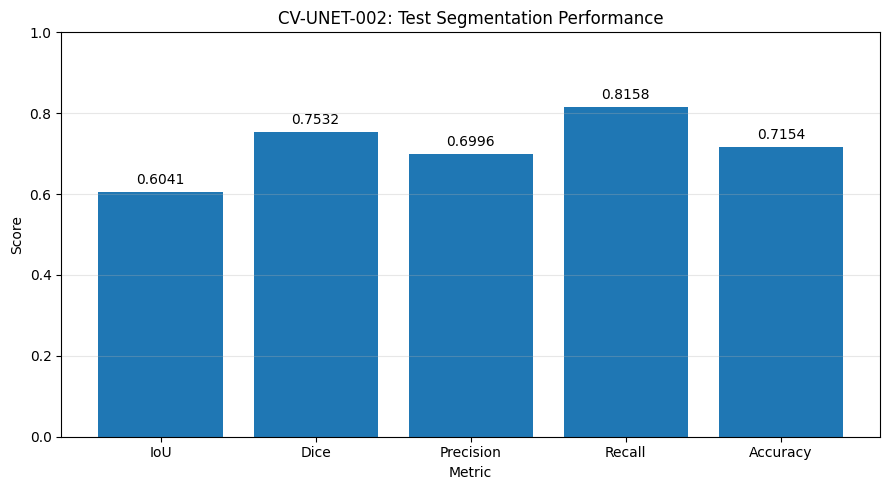

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path

metrics = {
    "IoU": iou,
    "Dice": dice,
    "Precision": precision,
    "Recall": recall,
    "Accuracy": accuracy
}

figures_dir = Path("/content/PetroVision/results/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    metrics.keys(),
    metrics.values()
)

plt.ylim(0, 1)
plt.xlabel("Metric")
plt.ylabel("Score")
plt.title("CV-UNET-002: Test Segmentation Performance")

for bar, value in zip(bars, metrics.values()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.02,
        f"{value:.4f}",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    figures_dir / "cv_unet_002_test_metrics.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 10. Qualitative Analysis

Quantitative metrics provide an overall measurement of segmentation
performance, but they do not show how the model behaves on individual
images.

Therefore, representative samples from the unseen test set are visualized
to compare:

- the original RGB image
- the ground-truth segmentation mask
- the CV-UNET-002 predicted mask
- an overlay of the prediction on the original image

The same test samples used for CV-UNET-001 are used here to enable a consistent comparison using the same dataset split and evaluation procedure between the two experiments.

The visualization helps identify:

- correctly detected target regions
- missed target regions
- false-positive regions
- boundary alignment
- over-segmentation
- under-segmentation

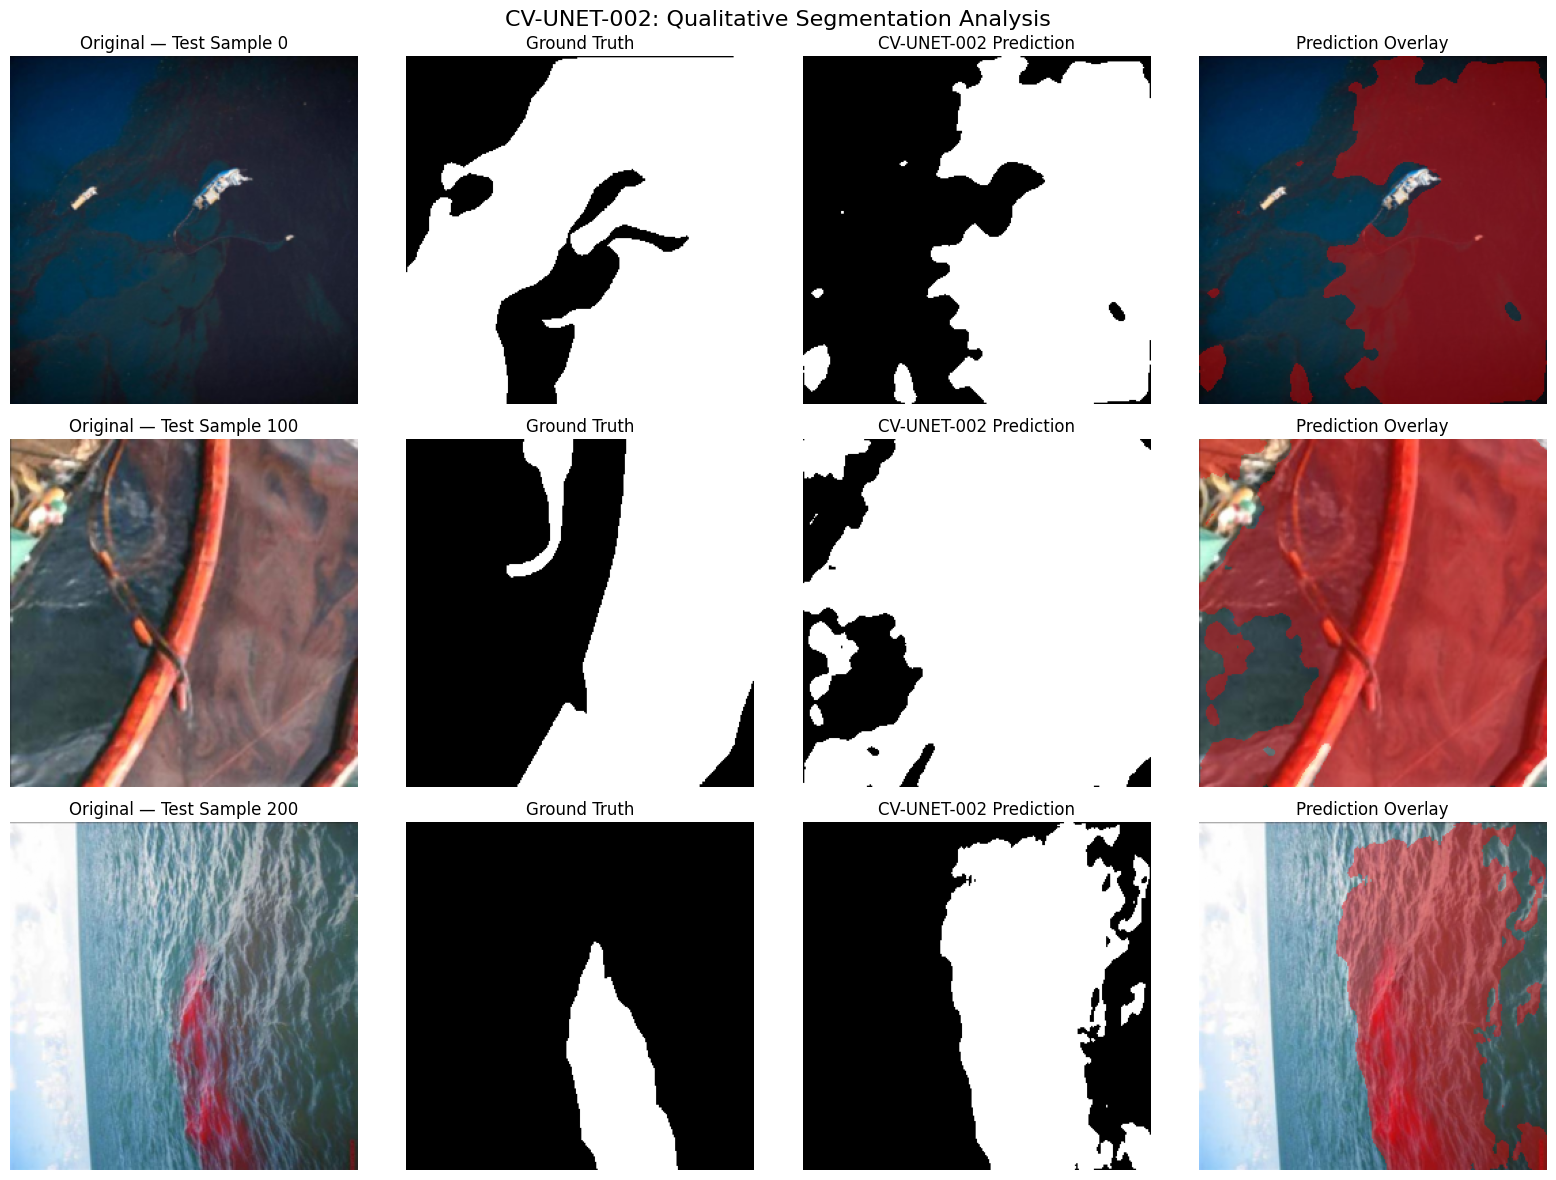

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from pathlib import Path

sample_indices = [0, 100, 200]

figures_dir = Path("/content/PetroVision/results/figures")
figures_dir.mkdir(parents=True, exist_ok=True)


def predict_single_sample(dataset, index, model, device):

    image_tensor, mask_tensor = dataset[index]

    image_input = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(image_input)
        probabilities = torch.sigmoid(logits)

    prediction = (probabilities >= 0.5).float()

    image = image_tensor.permute(1, 2, 0).cpu().numpy()
    ground_truth = mask_tensor.squeeze(0).cpu().numpy()
    prediction = prediction.squeeze().cpu().numpy()

    return image, ground_truth, prediction


model.eval()

fig, axes = plt.subplots(
    len(sample_indices),
    4,
    figsize=(16, 4 * len(sample_indices))
)

if len(sample_indices) == 1:
    axes = np.expand_dims(axes, axis=0)


for row, index in enumerate(sample_indices):

    image, ground_truth, prediction = predict_single_sample(
        test_dataset,
        index,
        model,
        DEVICE
    )

    overlay = image.copy()

    overlay[prediction == 1] = (
        0.6 * overlay[prediction == 1]
        + 0.4 * np.array([1.0, 0.0, 0.0])
    )

    axes[row, 0].imshow(image)
    axes[row, 0].set_title(
        f"Original — Test Sample {index}"
    )
    axes[row, 0].axis("off")

    axes[row, 1].imshow(
        ground_truth,
        cmap="gray"
    )
    axes[row, 1].set_title("Ground Truth")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(
        prediction,
        cmap="gray"
    )
    axes[row, 2].set_title("CV-UNET-002 Prediction")
    axes[row, 2].axis("off")

    axes[row, 3].imshow(overlay)
    axes[row, 3].set_title("Prediction Overlay")
    axes[row, 3].axis("off")


plt.suptitle(
    "CV-UNET-002: Qualitative Segmentation Analysis",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    figures_dir / "cv_unet_002_qualitative_analysis.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 11. Pixel-Level Error Analysis

Pixel-level error analysis is used to understand how CV-UNET-002 makes
correct and incorrect segmentation predictions across the complete unseen
test set.

Each pixel is categorized as:

- True Positive (TP): predicted target and ground truth target
- False Positive (FP): predicted target but ground truth non-target
- False Negative (FN): predicted non-target but ground truth target
- True Negative (TN): predicted non-target and ground truth non-target

These values provide additional context for interpreting precision, recall,
IoU, and Dice.

The analysis is performed on the complete test set rather than on individual
sample images.

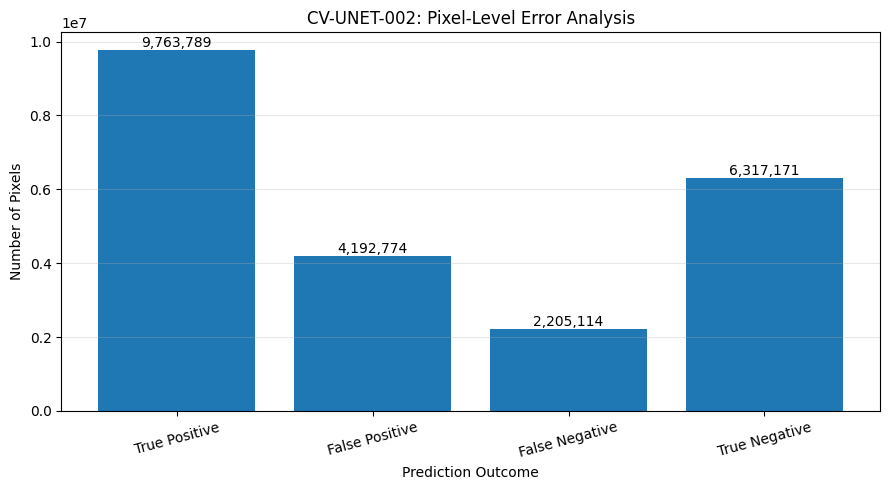

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path

labels = [
    "True Positive",
    "False Positive",
    "False Negative",
    "True Negative"
]

values = [
    TP,
    FP,
    FN,
    TN
]

figures_dir = Path("/content/PetroVision/results/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    labels,
    values
)

plt.ylabel("Number of Pixels")
plt.xlabel("Prediction Outcome")
plt.title("CV-UNET-002: Pixel-Level Error Analysis")

plt.xticks(rotation=15)

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:,}",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    figures_dir / "cv_unet_002_pixel_error_analysis.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 12. Baseline vs Improvement Comparison

CV-UNET-002 was designed as a controlled loss-function experiment based on
the CV-UNET-001 baseline.

CV-UNET-001 uses a combined BCE + Dice loss, whereas CV-UNET-002 uses Dice
Loss alone.

The two experiments use the same:

- LADOS dataset
- train/validation/test split
- U-Net architecture
- image resolution
- batch size
- number of training epochs
- optimizer
- learning rate
- data augmentation strategy
- test-set evaluation procedure

The intended experimental difference is the segmentation loss function; run-to-run stochastic variation may also contribute to observed differences.

The following comparison visualizes the resulting test metrics to examine
how the change in loss function affects segmentation behaviour.

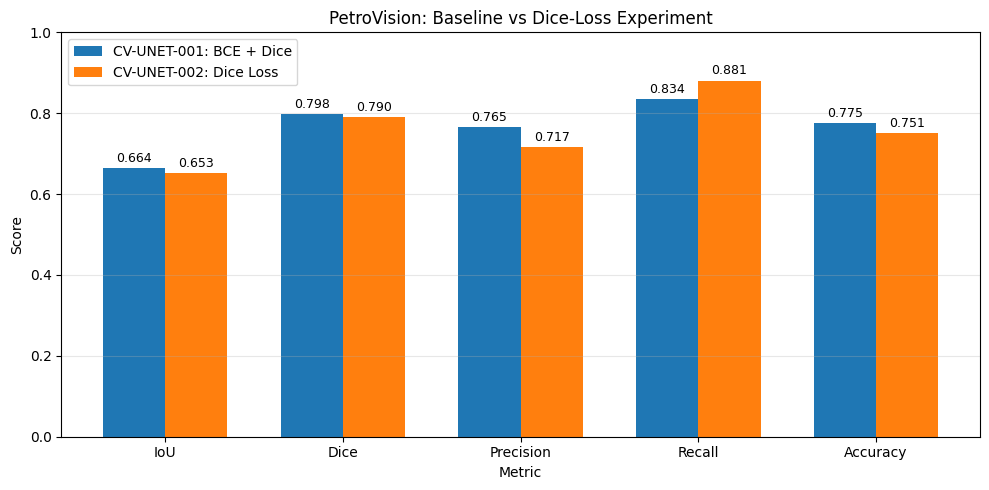

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

baseline_metrics = {
    "IoU": 0.6638,
    "Dice": 0.7979,
    "Precision": 0.7648,
    "Recall": 0.8340,
    "Accuracy": 0.7751
}

improvement_metrics = {
    "IoU": 0.6041,
    "Dice": 0.7532,
    "Precision": 0.6996,
    "Recall": 0.8158,
    "Accuracy": 0.7154
}

metric_names = list(baseline_metrics.keys())

baseline_values = [
    baseline_metrics[m]
    for m in metric_names
]

improvement_values = [
    improvement_metrics[m]
    for m in metric_names
]

x = np.arange(len(metric_names))
width = 0.35

figures_dir = Path("/content/PetroVision/results/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 5))

bars1 = plt.bar(
    x - width / 2,
    baseline_values,
    width,
    label="CV-UNET-001: BCE + Dice"
)

bars2 = plt.bar(
    x + width / 2,
    improvement_values,
    width,
    label="CV-UNET-002: Dice Loss"
)

plt.ylim(0, 1)
plt.xlabel("Metric")
plt.ylabel("Score")
plt.title("PetroVision: Baseline vs Dice-Loss Experiment")

plt.xticks(
    x,
    metric_names
)

plt.legend()
plt.grid(axis="y", alpha=0.3)

for bars in [bars1, bars2]:

    for bar in bars:

        value = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.015,
            f"{value:.3f}",
            ha="center",
            fontsize=9
        )

plt.tight_layout()

plt.savefig(
    figures_dir / "cv_unet_001_vs_002_metrics.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

## 13. Results and Interpretation

CV-UNET-002 was evaluated on 343 previously unseen test images.

The results are compared with the CV-UNET-001 baseline:

| Metric | CV-UNET-001 | CV-UNET-002 |
|---|---:|---:|
| IoU | 0.6638 | 0.6041 |
| Dice | 0.7979 | 0.7532 |
| Precision | 0.7648 | 0.6996 |
| Recall | 0.8340 | 0.8158 |
| Accuracy | 0.7751 | 0.7154 |

The recorded Dice-Loss experiment produced lower IoU, Dice, precision, recall, and accuracy than the recorded BCE + Dice baseline. This indicates that, under the current experimental configuration, Dice Loss alone did not improve the evaluated segmentation metrics.

However, precision decreased, indicating an increase in predicted target
pixels that did not correspond to the ground-truth target regions.

The overall IoU and Dice scores were also lower for CV-UNET-002 under the
current experimental configuration.

Therefore, the experiment demonstrates a measurable precision-recall
trade-off rather than an overall improvement across all segmentation
metrics.

This controlled experiment provides evidence about the effect of using
Dice Loss alone and will be considered when selecting configurations for
subsequent PetroVision experiments.

These results represent the current experimental runs and should not be interpreted as evidence that Dice Loss is universally inferior to BCE + Dice. Additional controlled runs with multiple random seeds would provide stronger evidence about the effect of the loss function.

## 14. Save Results

The experiment outputs are saved for reproducibility and later comparison.

The saved outputs include:

- training and validation loss curve
- test-set metric visualization
- qualitative segmentation visualization
- pixel-level error analysis
- baseline-versus-improvement comparison

The trained model checkpoint is also retained separately from the source
code and dataset.

Large datasets and model files are not committed to the GitHub repository.

In [ ]:
from pathlib import Path

figures_dir = Path("/content/PetroVision/results/figures")

print("Saved visualization files:")

for file in sorted(figures_dir.glob("cv_unet_002*.png")):
    print("-", file.name)

print("\nBaseline comparison:")
comparison_file = figures_dir / "cv_unet_001_vs_002_metrics.png"

print(
    "Found" if comparison_file.exists() else "Not found",
    comparison_file
)

Saved visualization files:
- cv_unet_002_loss_curve.png
- cv_unet_002_pixel_error_analysis.png
- cv_unet_002_qualitative_analysis.png
- cv_unet_002_test_metrics.png

Baseline comparison:
Found /content/PetroVision/results/figures/cv_unet_001_vs_002_metrics.png
